# OBS: O ALGORITMO FOI IMPLEMENTADO APENAS PARA FUNCIONAR, NÃO ESTANDO OTIMIZADO AINDA, MAS SERÁ OTIMIZADO EM BREVE.

#Biblioteca

In [ ]:
import numpy as np # manipulação de vetores e matrizes
import plotly.graph_objects as go # manipulação de gráficos
from scipy.signal import square  # importa onda quadrada
from scipy.integrate import quad #calcula integrais

#Funções


In [ ]:
def Onda_quadrada(t):
  T = 2 * np.pi
  return float(square(2 * np.pi * (1/T) * t))

def integrando(t,n):
  T = 2 * np.pi
  return Onda_quadrada(t) * np.exp(-1j * 2 * np.pi* n * (1/T) * t)



def plot (x_t):
  t = np.linspace(0,2*np.pi,10000)
  fig = go.Figure()
  fig.add_trace(go.Scatter(x=t, y=x_t.real, mode='lines', name='Onda Quadrada'))

  fig.update_layout(
      title="Sinal reconstruido a partir da serie de fourier",
      xaxis_title= "Tempo (s)",
      yaxis_title= "Amplitude",
      template="plotly_white"
      )
  fig.show()


<img src="https://drive.google.com/uc?export=view&id=1EgaC-v4emHxFY95t2Zwg1mYn0Ki8ZCv-"
     width="500"
     style="display: block; margin-left: auto; margin-right: auto;">


<img src="https://drive.google.com/uc?export=view&id=1iEGkg2vt9Ez1jQaLg3B4bHUYMrZZyHvy"
     width="500"
     style="display: block; margin-left: auto; margin-right: auto;">



#Implementação

In [ ]:
N = 100
T = 2* np.pi
Cn_val = np.array([])
x_t_re_val = np.array([])
t = np.linspace(0,2*np.pi)
C_n = 0
x_t_re = 0
x_t_ree = np.array([])

for n in range(-N,N+1):
  C_n = (1/T) * (quad(lambda t_: np.real(integrando(t_, n)), 0, T)[0] + 1j * quad(lambda t_: np.imag(integrando(t_, n)), 0, T)[0])
  Cn_val = np.append(Cn_val, C_n) #apenas salva os valores de Cn_val


for t_ in t:
  for n in range(-N,N+1):
    x_t_re = Cn_val[n + N] * np.exp(1j * 2 * np.pi * n * (1/T) * t_)
    x_t_ree = np.append(x_t_ree, x_t_re)


  x_t_re_val = np.append(x_t_re_val, sum(x_t_ree))
  x_t_ree = np.array([])




'''esse é a serie de fourier para sinais genericos, quando se conhece previamente
o sinal de entrada é possivel realizar simplificações, antes de operar
e assim obter um melhor resultado'''



/tmp/ipython-input-20-893192608.py:11: IntegrationWarning:

The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.



'esse é a serie de fourier para sinais genericos, quando se conhece previamente\no sinal de entrada é possivel realizar simplificações, antes de operar\ne assim obter um melhor resultado'

#Gráfico Gerado

In [ ]:
plot(x_t_re_val)

# Complementares (realização de testes para melhoras futuras)


In [ ]:
import sympy as sp

# Número de variáveis
n = 5

# Cria C_1, C_2, ..., C_5
C = sp.symbols(f'C1:{n+1}')  # C1 até Cn inclusive (por isso n+1)

# Exibe as variáveis criadas
print("Variáveis simbólicas:", C)

# Exemplo: Soma dos C_i
S = sum(C)
print("Soma simbólica S = ", S)

# Agora podemos fazer cálculos simbólicos com esses C_i
produto = C[0] * C[1] + C[2]**2 + 1 - C[0]
print("Exemplo de expressão simbólica:", produto)


Variáveis simbólicas: (C1, C2, C3, C4, C5)
Soma simbólica S =  C1 + C2 + C3 + C4 + C5
Exemplo de expressão simbólica: C1*C2 - C1 + C3**2 + 1


In [ ]:
import sympy as sp

n = 5
x_simbolos = sp.symbols('x1:%d' % (n + 1))

vetor_simbolos = sp.Matrix(x_simbolos)
for i,n in enumerate(vetor_simbolos):
  print(f"x{i} = {n}")
print(vetor_simbolos)

x0 = x1
x1 = x2
x2 = x3
x3 = x4
x4 = x5
Matrix([[x1], [x2], [x3], [x4], [x5]])


In [ ]:
#utiliando calculo matricial para serie de fourier
from tabulate import tabulate

# Converter para lista de listas de strings (que interpretado pelo tabulate)
vetor_tabulado = [[str(val)] for val in vetor_simbolos]

# Usar tabulate com estilo 'fancy_grid'
print(tabulate(vetor_tabulado, headers="", tablefmt="fancy_grid"))




╒════╕
│ x1 │
├────┤
│ x2 │
├────┤
│ x3 │
├────┤
│ x4 │
├────┤
│ x5 │
╘════╛


## como ficará a serie de fourier na forma matricial?

In [ ]:
import sympy as sp
from tabulate import tabulate

# Número de elementos
N = 3

# Criando vetores simbólicos
n_syms = sp.symbols(f'n1:{N+1}')  # n1, n2, n3
t_syms = sp.symbols(f't1:{N+1}')  # t1, t2, t3
x_syms = sp.symbols(f'x1:{N+1}')  # x1, x2, x3
print(n_syms)
# Vetores como colunas
n_vec = sp.Matrix(n_syms).reshape(N, 1)
t_vec = sp.Matrix(t_syms).reshape(N, 1)
x_vec = sp.Matrix(x_syms).reshape(N, 1)

# Criar matriz A[i,j] = n[i] + t[j]
A = sp.Matrix(N, N, lambda i, j: n_vec[i] + t_vec[j])

# Multiplicação
y = A * x_vec

# Para exibir A no tabulate
A_str = [[str(A[i, j]) for j in range(A.cols)] for i in range(A.rows)]
print("\nMatriz A (n[i] + t[j]):")
print(tabulate(A_str, tablefmt="fancy_grid"))

# Para exibir x no tabulate
x_str = [[str(x_vec[i, 0])] for i in range(N)]
print("\nVetor x:")
print(tabulate(x_str, tablefmt="fancy_grid"))

# Para exibir y no tabulate
y_str = [[str(y[i, 0])] for i in range(N)]
print("\nResultado y = A * x:")
print(tabulate(y_str, tablefmt="fancy_grid"))


(n1, n2, n3)

Matriz A (n[i] + t[j]):
╒═════════╤═════════╤═════════╕
│ n1 + t1 │ n1 + t2 │ n1 + t3 │
├─────────┼─────────┼─────────┤
│ n2 + t1 │ n2 + t2 │ n2 + t3 │
├─────────┼─────────┼─────────┤
│ n3 + t1 │ n3 + t2 │ n3 + t3 │
╘═════════╧═════════╧═════════╛

Vetor x:
╒════╕
│ x1 │
├────┤
│ x2 │
├────┤
│ x3 │
╘════╛

Resultado y = A * x:
╒════════════════════════════════════════════╕
│ x1*(n1 + t1) + x2*(n1 + t2) + x3*(n1 + t3) │
├────────────────────────────────────────────┤
│ x1*(n2 + t1) + x2*(n2 + t2) + x3*(n2 + t3) │
├────────────────────────────────────────────┤
│ x1*(n3 + t1) + x2*(n3 + t2) + x3*(n3 + t3) │
╘════════════════════════════════════════════╛


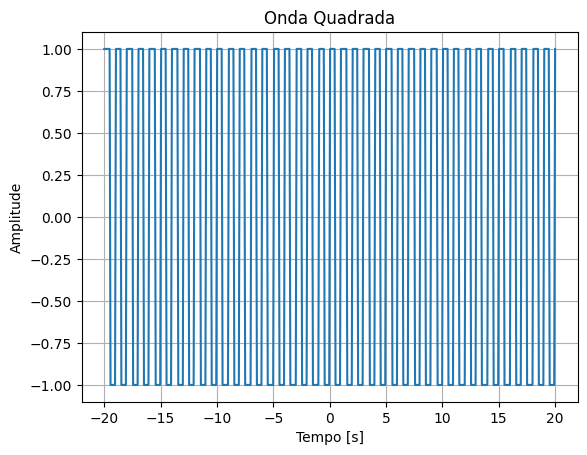

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import square

t = np.linspace(-20, 20, 500)    # eixo do tempo
freq = 1                     # frequência da onda quadrada em Hz

# Gerar onda quadrada
y = square(2 * np.pi * freq * t)

# Plot
plt.plot(t, y)
plt.title('Onda Quadrada')
plt.xlabel('Tempo [s]')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()


In [ ]:

N = 4 # Tamanho do vetor

c_4 = sp.symbols(f"C_1:{N+1}") #cria tupla de simbolos C_n

c_4m = sp.Matrix(c_4) #cria vetor de simbolos


print(c_4m.shape) # verifica as linhas e colunas
print("\n")
sp.pprint(c_4m) # verifica o vetor
print("\n")


n = sp.symbols(f"{N}") # simbolos para n do somatório

print(n)


(4, 1)


⎡C₁⎤
⎢  ⎥
⎢C₂⎥
⎢  ⎥
⎢C₃⎥
⎢  ⎥
⎣C₄⎦


4


In [ ]:
n, m = 3, 3  # dimensões da matriz
simbolos = [[sp.Symbol(f'a{i+1}{j+1}') for j in range(m)] for i in range(n)]

A = sp.Matrix(simbolos)

sp.pprint(A)


⎡a₁₁  a₁₂  a₁₃⎤
⎢             ⎥
⎢a₂₁  a₂₂  a₂₃⎥
⎢             ⎥
⎣a₃₁  a₃₂  a₃₃⎦


In [ ]:
n = 'n'
simbolos = [sp.Symbol(f'x_{{{i}}}^{{{n}}}') for i in range(1, 5)]

vetor = sp.Matrix(simbolos)

sp.pprint(vetor)


⎡x_{1}__{n}⎤
⎢          ⎥
⎢x_{2}__{n}⎥
⎢          ⎥
⎢x_{3}__{n}⎥
⎢          ⎥
⎣x_{4}__{n}⎦


In [ ]:
import sympy as sp
from IPython.display import display, Math

# Matriz 3x3 com A_{i}^{j}
A = sp.Matrix([[sp.Symbol(f'A_{{{i}}}^{{{j}}}') for j in range(1, 4)]
               for i in range(1, 4)])

# Exibir como LaTeX
display(Math(sp.latex(A)))


<IPython.core.display.Math object>

In [ ]:
import sympy as sp
from IPython.display import display, Math

# Vetores simbólicos n e t
n_vals = sp.symbols('n0:3')  # n0, n1, n2
t_vals = sp.symbols('t0:3')  # t0, t1, t2

n_vec = sp.Matrix(n_vals).reshape(len(n_vals), 1)  # vetor coluna n
t_vec = sp.Matrix(t_vals).reshape(len(t_vals), 1)  # vetor coluna t

# Função para elementos da matriz: exp(n_i * t_j)
def f(i, j):
    return sp.exp(n_vec[i] * t_vec[j])

# Criar matriz A sem for explícito, usando lambda
A = sp.Matrix(len(n_vec), len(t_vec), lambda i, j: f(i, j))

# Vetor x com símbolos
x = sp.Matrix(sp.symbols(f'x0:{len(t_vec)}')).reshape(len(t_vec), 1)

# Multiplicação matricial direta (sem for)
y = A * x

# Exibir a matriz A e o resultado y em LaTeX
display(Math(r"A = " + sp.latex(A)))
display(Math(r"y = A \times x = " + sp.latex(y)))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [ ]:
N = 4
x = sp.symbols(f"x0{N}")
w = sp.symbols("e^(2*pi*1/T)")

In [ ]:
import sympy as sp

# Definindo símbolos
pi = sp.pi
T = sp.symbols('T', real=True, positive=True)  # por exemplo
i = sp.I  # unidade imaginária (sqrt(-1))
e = sp.symbols("e")
# Definindo w como exponencial

display(Math(r"y = A \times x = " + sp.latex(e**(2 * pi * 1/T * i))))


<IPython.core.display.Math object>

In [ ]:
t = np.linspace(0,1,2*N)

print(t)

[0.         0.14285714 0.28571429 0.42857143 0.57142857 0.71428571
 0.85714286 1.        ]


In [ ]:
N = 4
T = 2
c_4 = sp.symbols([f"C_{{{i}}}" for i in range(-N,N+1)])

n = sp.symbols([f"{i}" for i in range(-N,N+1)])

t = sp.symbols([str(((np.linspace(0,1,2*N+1)).tolist())[i]) for i in range(0,2*N+1)])

#------------------------
e = sp.symbols("e")
pi = sp.pi
i = sp.symbols("i")
#------------------------

W_T = sp.symbols("W_{T}")

c_4 = sp.Matrix(c_4)
n = sp.Matrix(n)
t = sp.Matrix(t)



# x = W_T**(t * n.T) não da certo devido a operação com matrizes e simbolos simultanemante

x = (t * n.T).applyfunc(lambda e: W_T**e)


display(Math(r""+ sp.latex(x)))

<IPython.core.display.Math object>

In [ ]:
import sympy as sp
import numpy as np
from sympy import symbols, Matrix, pi, latex
from IPython.display import display, Math

# Parâmetros
N = 4
T = 2

# Símbolos
c_4 = sp.symbols([f"C_{{{i}}}" for i in range(-N, N + 1)])
n = sp.symbols([f"{i}" for i in range(-N, N + 1)])
t = sp.symbols([str(((np.linspace(0, 1, 2 * N + 1)).tolist())[i]) for i in range(2 * N + 1)])
e = sp.symbols("e")
i = sp.symbols("i")
W_T = sp.symbols("W_{T}")

# Matrizes
c_4 = Matrix(c_4)
n = Matrix(n)
t = Matrix(t)

# Matriz simbólica
x = (t * n.T).applyfunc(lambda e: W_T**e)

# Função para gerar LaTeX com espaçamento entre linhas e colunas
def latex_matrix_with_spacing(matrix, col_spacing="0.9cm", row_spacing="1.2em"):
    lines = []
    for row_idx in range(matrix.shape[0]):
        row_exprs = []
        for col_idx in range(matrix.shape[1]):
            expr = latex(matrix[row_idx, col_idx])
            # Adiciona espaçamento entre colunas
            row_exprs.append(r"\hspace{{{}}}{}".format(col_spacing, expr))
        # Adiciona espaçamento entre linhas
        line = r"\rule{0pt}{" + row_spacing + r"} " + " & ".join(row_exprs)
        lines.append(line)
    # Monta matriz com colchetes usando array
    latex_code = r"\left[\begin{array}{" + "c" * matrix.shape[1] + "}" + r" \\ ".join(lines) + r"\end{array}\right]"
    return latex_code

# Gerar LaTeX e exibir
latex_code = latex_matrix_with_spacing(x, col_spacing="0.0cm", row_spacing="3em") + "\cdot" + latex_matrix_with_spacing(c_4, col_spacing="0.0cm", row_spacing="3em")
display(Math(latex_code))


<IPython.core.display.Math object>

In [ ]:
#agora fazer procedimento de calculo propriamente utilizando numpy
def onda(t,fs):
  return np.sign(np.sin(2 * np.pi * fs * t))

T = 2 * np.pi

n = np.arange(-N,N+1,1)

t = np.linspace(0,T, 2*N+1)

W_T = np.exp(2j * np.pi * 1/T)

W = W_T**(t * n.T)

print(W)




C_n = [(1/T) * (fixed_quad(lambda t: np.real(onda(t, fs) * np.exp(-1j * 2 * np.pi * (1 / T) * t * n)), 0, T, n=20)[0] +
                1j * fixed_quad(lambda t: np.imag(onda(t, fs) * np.exp(-1j * 2 * np.pi * (1 / T) * t * n)), 0, T, n=20)[0])
                 for n in range(-N,N+1)]






[ 1.00000000e+00+0.00000000e+00j -9.51056516e-01-3.09016994e-01j
  3.09016994e-01+9.51056516e-01j  9.51056516e-01-3.09016994e-01j
  3.09016994e-01-9.51056516e-01j  3.06161700e-16-1.00000000e+00j
  3.09016994e-01-9.51056516e-01j  9.51056516e-01-3.09016994e-01j
  3.09016994e-01+9.51056516e-01j -9.51056516e-01-3.09016994e-01j
  1.00000000e+00+0.00000000e+00j -9.51056516e-01-3.09016994e-01j
  3.09016994e-01+9.51056516e-01j  9.51056516e-01-3.09016994e-01j
  3.09016994e-01-9.51056516e-01j -2.69484194e-15-1.00000000e+00j
  3.09016994e-01-9.51056516e-01j  9.51056516e-01-3.09016994e-01j
  3.09016994e-01+9.51056516e-01j -9.51056516e-01-3.09016994e-01j
  1.00000000e+00-2.44929360e-15j]


In [ ]:
N = 10
T = 2 * np.pi
fs = 1/T
t = np.linspace(0, T, 1000)






C_-10 = (5.551115123125783e-17-0.6397217253584832j)
C_-9 = (-9.54097911787244e-17+0.006334052717126822j)
C_-8 = (7.979727989493313e-17-0.2220502265565506j)
C_-7 = (8.673617379884035e-18+0.013817374685411297j)
C_-6 = (-1.196959198423997e-16-0.1458399733631127j)
C_-5 = (-3.5561831257524545e-16+0.02433729244549852j)
C_-4 = (6.800116025829084e-16-0.12289086980960381j)
C_-3 = (-7.806255641895632e-17+0.042581737211831894j)
C_-2 = (-1.1275702593849246e-16-0.1297485657492917j)
C_-1 = (-8.638922910364499e-16+0.08864886337207954j)
C_0 = (-8.638922910364499e-16-0.08864886337207954j)
C_1 = (-1.1275702593849246e-16+0.1297485657492917j)
C_2 = (-7.806255641895632e-17-0.042581737211831894j)
C_3 = (6.800116025829084e-16+0.12289086980960381j)
C_4 = (-3.5561831257524545e-16-0.02433729244549852j)
C_5 = (-1.196959198423997e-16+0.1458399733631127j)
C_6 = (8.673617379884035e-18-0.013817374685411297j)
C_7 = (7.979727989493313e-17+0.2220502265565506j)
C_8 = (-9.54097911787244e-17-0.006334052717126822j)
C_9 = (

In [ ]:
import numpy as np
from scipy.integrate import fixed_quad

T = 2 * np.pi
freq = 1 / T  # frequência numérica

def onda(t, freq):
    return np.sign(np.sin(2 * np.pi * freq * t))

# Agora a função para integrar, por exemplo a parte real do coeficiente de Fourier n=1
n = 1
def integrando(t):
    return onda(t, freq) * np.exp(-1j * 2 * np.pi * n * t / T)

real_part, _ = fixed_quad(lambda t: np.real(integrando(t)), 0, T, n=20)
imag_part, _ = fixed_quad(lambda t: np.imag(integrando(t)), 0, T, n=20)

C_n = (1/T) * (real_part + 1j * imag_part)

print(f"C_{n} = {C_n:.8f}")


C_1 = -0.00000000-0.63972173j
